# GW parameter estimation with PTMCMC

We use the IMRPhenomD $h_{22}$ waveform model to simulate (noise-free) data and recover the parameters via parallel tempering MCMC. The noise weighted inner product uses the aLIGO theoretical noise PSD. All inner products, likelihood evaluations, etc. are conducted in the frequency-domain.

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from corner import corner
from scipy.stats import multivariate_normal

import wave_gen as wg
import data as d
import likelihood as l
import jumps as j
from PTMCMC import PTMCMC

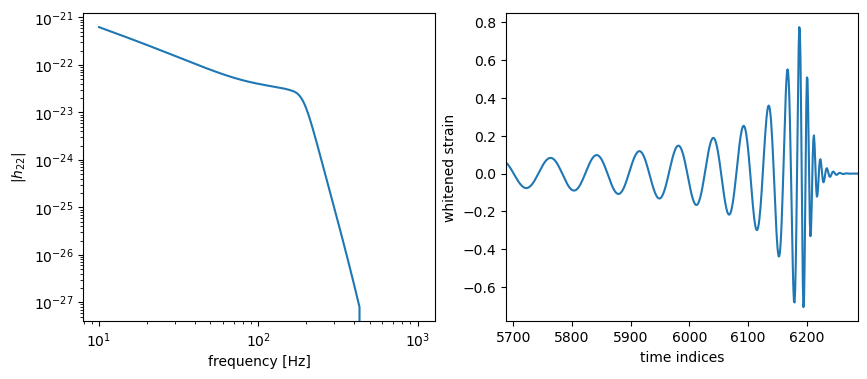

In [3]:
# plot injected waveforms (data) in frequency- and time-domain

## frequency-domain
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.loglog(wg.f, d.data_amp)
plt.xlabel('frequency [Hz]')
plt.ylabel(r'$|h_{22}|$')

## time-domain
plt.subplot(1, 2, 2)
#pad lower frequencies for iFFT
npad = int(wg.f[0] / wg.df)
whitened_FD_waveform = np.pad(d.data_FD_waveform / l.sqrtS, (npad, 0))
TD_waveform = np.fft.irfft(whitened_FD_waveform)
TD_waveform = np.roll(TD_waveform, TD_waveform.shape[0] // 2)
plt.plot(TD_waveform)
plt.xlim(np.argmax(TD_waveform) - 500, np.argmax(TD_waveform) + 100)
plt.xlabel('time indices')
plt.ylabel('whitened strain')

plt.show()

In [5]:
# jump proposals
Fisher = j.Fisher(d.x_inj)
diff_evol = j.DifferentialEvolution(len_history=100)
prior_draw = j.PriorDraw()
jump_proposals = [[Fisher.vectorized_Fisher_jump, 20],
                  [diff_evol.vectorized_DE_jump, 20],
                  [prior_draw.vectorized_prior_draw, 0.91370559]] # << 1.5% chance of prior draw (given weight=20 for other 3 jump types)

# do PTMCMC!
num_samples = int(1e5)
num_chains = 15
temp_ladder = 1.5**np.arange(num_chains)

samples, lnposts = PTMCMC(num_samples=num_samples,
                          num_chains=num_chains,
                          x0=d.x_inj,
                          ln_posterior_func=l.ln_posterior,
                          jump_proposals=jump_proposals,
                          temp_ladder=temp_ladder,
                          PT_swap_weight=20)

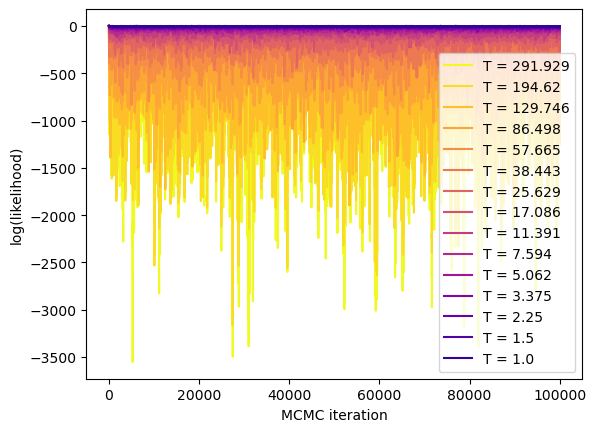

In [6]:
# plot likelihood values of chains (without temperature scaling)

chain_colors = list(reversed([plt.cm.plasma(i / num_chains) for i in range(1, num_chains + 1)]))

for j, (temp, color) in enumerate(zip(temp_ladder[::-1], chain_colors)):
    plt.plot(lnposts[::-1][j] * temp, color=color, label=f'T = {round(temp, 3)}')
plt.xlabel('MCMC iteration')
plt.ylabel('log(likelihood)')
plt.legend(loc='lower right')
plt.show()

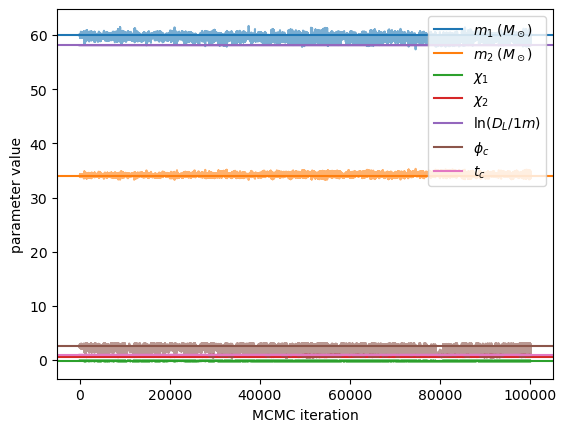

In [7]:
# trace plot for T = 1 chain
for i in range(wg.ndim):
    plt.plot(samples[0,:,i], color=f'C{i}', alpha=0.6)
    plt.axhline(d.x_inj[i], color=f'C{i}', alpha=1, label=wg.x_labels[i])
plt.xlabel('MCMC iteration')
#plt.ylim(0.95*d.x_inj[-1],1.05*d.x_inj[-1]) # zoom into t_c
plt.ylabel('parameter value')
plt.legend(loc='upper right')
plt.show()

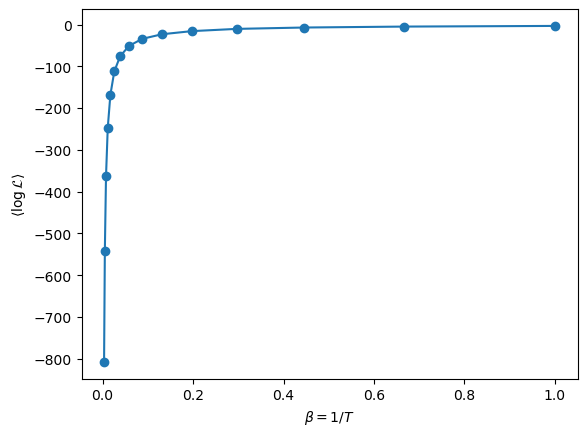

In [8]:
# average log-likelood over temperatures
burnin = num_samples // 5
avg_lnlikes = np.mean(lnposts[:, burnin:], axis=1) * temp_ladder
betas = 1. / temp_ladder
plt.plot(betas, avg_lnlikes, marker='o')
plt.xlabel(r'$\beta = 1 / T$')
plt.ylabel(r'$\langle\log\mathcal{L}\rangle$')
plt.show()

dm1=1.5893383915701165, dm2=0.3258027614801707,
dm=1.915141153050287 -> 4dm=7.660564612201148


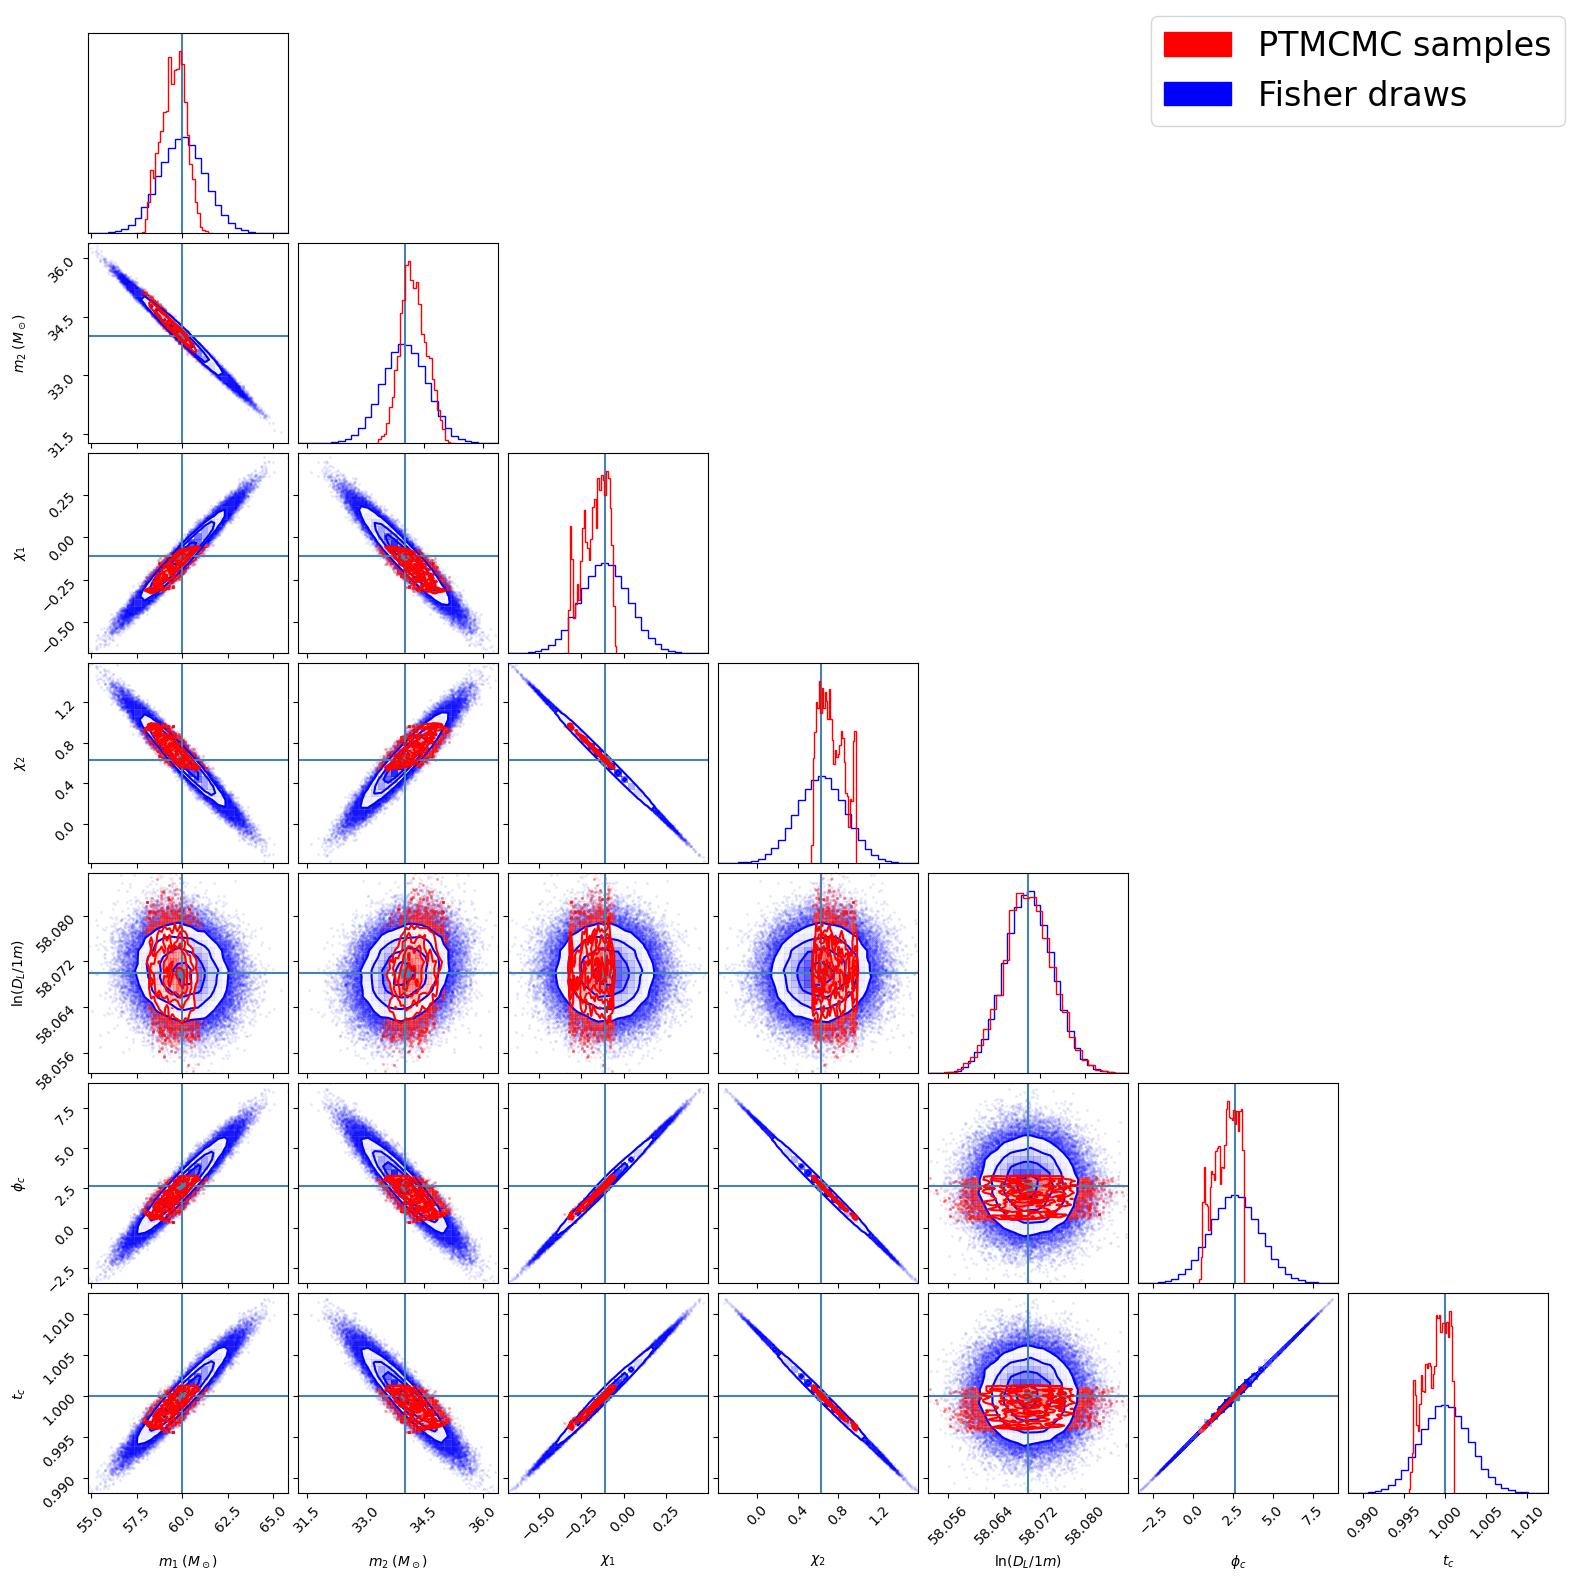

In [ ]:
### Corner plots
# This routine is identical to lmcmc.cornerplots(samples, _Lambda=0)

# Fisher samples
cov = np.linalg.inv(Fisher.Fisher)

# For defining an appropriate f_IM: examine dm=dm1+dm2. Dry run 8/4/26
print(f'dm1={cov[0,0]}, dm2={cov[1,1]},\ndm={cov[0,0]+cov[1,1]} -> 4dm={4*(cov[0,0]+cov[1,1])}')

#cov += np.full(np.shape(cov), 1.e-9) # if allow_singular below is to be False, bump up the catastrophically finite-differenced values of cov by the smallest amount acceptable by multivariate_normal
Fisher_samples = multivariate_normal(d.x_inj, cov, allow_singular=True).rvs(num_samples - burnin)
fisher_n = Fisher_samples.shape[0]
fisher_weights = np.full(fisher_n, 1.0 / fisher_n)

fig = corner(
    Fisher_samples,
    truths=d.x_inj,
    labels=wg.x_labels,
    color='blue',
    bins=30,
    hist_kwargs={'density': True},
    weights=fisher_weights,
)

# PTMCMC samples
pt_samples = samples[0, burnin:]
pt_n = pt_samples.shape[0]
pt_weights = np.full(pt_n, 1.0 / pt_n)

corner(
    pt_samples,
    color='red',
    fig=fig,
    bins=30,
    hist_kwargs={'density': True},
    weights=pt_weights,
)

red_patch = mpatches.Patch(color='red', label='PTMCMC samples')
blue_patch = mpatches.Patch(color='blue', label='Fisher draws')
handles, labels = plt.gca().get_legend_handles_labels()
handles += [red_patch, blue_patch]
fig.legend(handles=handles, loc='upper right', fontsize=24)
plt.show()


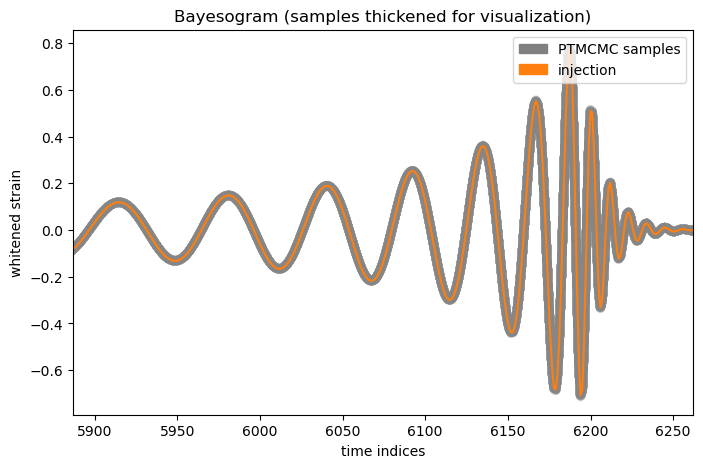

In [10]:
npad = int(wg.f[0] / wg.df)
whitened_FD_waveform_inj = np.pad(d.data_FD_waveform / l.sqrtS, (npad, 0))
TD_waveform_inj = np.fft.irfft(whitened_FD_waveform_inj)
roll_amt = TD_waveform_inj.shape[0] // 2
TD_waveform_inj = np.roll(TD_waveform_inj, roll_amt)

num_draws = 100
draw_ndxs = np.random.choice(np.arange(burnin, num_samples), num_draws)
plt.figure(figsize=(8, 5))
for ndx in draw_ndxs:
    whitened_FD_waveform = np.pad(wg.FD_waveform(samples[0, ndx]) / l.sqrtS, (npad, 0))
    TD_waveform = np.fft.irfft(whitened_FD_waveform)
    TD_waveform = np.roll(TD_waveform, roll_amt)
    plt.plot(TD_waveform, color='grey', alpha=1.0/num_draws, lw=7)
plt.plot(TD_waveform_inj, color='C1')
grey_patch = mpatches.Patch(color='grey', label='PTMCMC samples')
orange_patch = mpatches.Patch(color='C1', label='injection')
handles, labels = plt.gca().get_legend_handles_labels()
handles += [grey_patch, orange_patch]
plt.legend(handles=handles, loc='upper right')
plt.xlim(np.argmax(TD_waveform) - 300, np.argmax(TD_waveform) + 75)
plt.xlabel('time indices')
plt.ylabel('whitened strain')
plt.title('Bayesogram (samples thickened for visualization)')
plt.show()